In [1]:

import logging
from pathlib import Path

import numpy as np
import polars as pl
import pandas as pd
# from decimal import Decimal
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

from typing import Optional


In [2]:

class AvailableDatasets:
    """Available Datasets, returns request ID"""

    FULL_YEAR_2024__CME_JPY_V: str = "GLBX-20251028-HAE9P7SP3U"
    FULL_YEAR_2023__CME_JPY_V: str = "GLBX-20251116-MJ5JKQA9A4"
    FULL_YEAR_2022__CME_JPY_V: str = "GLBX-20251115-DJHUGKSLWB"


In [3]:

# WORKING DIRECTORY
MAIN_DIR = Path("/Users/number6/Projects/Bimini/")

# HISTORICAL DATA
HISTORICAL_DATA = MAIN_DIR / "0_data" / "historical"

# IMPORT PATH
PARQUET_DIR = HISTORICAL_DATA / "parquet"

# EXPORT PATH
EXPORT_DIR = MAIN_DIR / "journal_results"


In [4]:


"""

?

"""



TICK_SIZE = 0.00001




# # Convert START_DATE and END_DATE to nanosecond epochs (integers)
# START_DATE_NS = int(
#     datetime(
#         year=2022,
#         month=11,
#         day=10,
#         hour=8,
#         minute=0,
#         second=0,
#         tzinfo=timezone.utc,
#     ).timestamp() * 1e9
# )

# END_DATE_NS = int(
#     datetime(
#         year=2022,
#         month=11,
#         day=10,
#         hour=18,
#         minute=0,
#         second=0,
#         tzinfo=timezone.utc,
#     ).timestamp() * 1e9
# )

# Convert START_DATE and END_DATE to nanosecond epochs (integers)
# START_DATE_NS = int(
#     datetime(
#         year=2022,
#         month=11,
#         day=10,
#         hour=8,
#         minute=0,
#         second=0,
#         tzinfo=timezone.utc,
#     ).timestamp() * 1e9
# )

# END_DATE_NS = int(
#     datetime(
#         year=2022,
#         month=11,
#         day=10,
#         hour=18,
#         minute=0,
#         second=0,
#         tzinfo=timezone.utc,
#     ).timestamp() * 1e9
# )

START_DATE_NS = int(
    datetime(
        year=2024,
        month=7,
        day=8,
        hour=12,
        minute=0,
        second=0,
        tzinfo=timezone.utc,
    ).timestamp() * 1e9
)

END_DATE_NS = int(
    datetime(
        year=2024,
        month=7,
        day=12,
        hour=23,
        minute=0,
        second=0,
        tzinfo=timezone.utc,
    ).timestamp() * 1e9
)


hrf_start_dt = datetime.fromtimestamp(START_DATE_NS / 1e9, tz=timezone.utc)
hrf_end_dt = datetime.fromtimestamp(END_DATE_NS / 1e9, tz=timezone.utc)

print("START_DATE_NS", hrf_start_dt.strftime("%Y-%m-%d %H:%M:%S %Z"))
print("END_DATE_NS", hrf_end_dt.strftime("%Y-%m-%d %H:%M:%S %Z"))



START_DATE_NS 2024-07-08 12:00:00 UTC
END_DATE_NS 2024-07-12 23:00:00 UTC


In [5]:

# IB1500_DIR = Path("/Users/number6/Projects/Bimini/pool_vb100_ib1500/2214_Nov_15_25/bucket/interval/bucket_interval_consolidated.parquet")
IB1500_DIR = Path("/Users/number6/Projects/Bimini/pool_vb100_fb30/2313_Nov_21_25/bucket/fixed/bucket_fixed_consolidated.parquet")

# ============================================================================
# [START] - Import Filters
# ============================================================================

# Data files to glob for processing
IB_DATA_GLOB = pl.scan_parquet(str(IB1500_DIR))


# {IntervalBucket - 1500} [ ACTUAL FILTER REQUEST FOR PROCESSING ]

"""

Rolling average container

Container_Size > Search_Range

Thus only consider end time for each new interval of the rolling average that would be available in the time frame

imbalance_size_signed_ratio_atanh_mean

delta_midpoint_vwap_log_sum

"""


# ib_lf = (
#     IB_DATA_GLOB
#     .with_columns(
#         (pl.col("imbalance_size_signed_ratio_atanh_mean").rank(method="average").truediv(pl.len()) * 100).alias("imbalance_ecdf_pct")
#     )
#     .filter(
#         (pl.col("end_ts_ns").dt.epoch(time_unit="ns") >= START_DATE_NS) & 
#         (pl.col("end_ts_ns").dt.epoch(time_unit="ns") <= END_DATE_NS)
#     )
#     .select([
#         "id",
#         pl.col("start_ts_ns").dt.epoch(time_unit="ns").cast(pl.UInt64).alias("start_ts_ns"),
#         pl.col("end_ts_ns").dt.epoch(time_unit="ns").cast(pl.UInt64).alias("end_ts_ns"),
#         "time_elapsed_ns_total",
#         "pace_of_orders_mean",
#         "time_elapsed_ns_mean",
#         "imbalance_size_signed_ratio_mean",
#         "bucket_delta_imbalance_size_abs_ratio_mean_logit",
#         "imbalance_size_signed_ratio_atanh_mean",
#         "imbalance_ecdf_pct",
#     ])
#     .with_columns([
#         pl.from_epoch(pl.col("end_ts_ns"), time_unit="ns").alias("end_time"),
#         (pl.col("time_elapsed_ns_mean") / 1e9).alias("time_elapsed_ns_mean"),
#     ])
# ).collect()



'\n\nRolling average container\n\nContainer_Size > Search_Range\n\nThus only consider end time for each new interval of the rolling average that would be available in the time frame\n\nimbalance_size_signed_ratio_atanh_mean\n\ndelta_midpoint_vwap_log_sum\n\n'

In [6]:

# VB100_DIR = Path("/Users/number6/Projects/Bimini/pool_vb100_fb30/1721_Nov_21_25/volumebar/raw/volumebar_raw_consolidated.parquet")

VB100_DIR = Path("/Users/number6/Projects/Bimini/pool_vb100_fb30/2313_Nov_21_25/volumebar/raw/volumebar_raw_consolidated.parquet")

# Data files to glob for processing
VB_DATA_GLOB = pl.scan_parquet(str(VB100_DIR))

vb_lf = (
    VB_DATA_GLOB
    .filter(
        (pl.col("end_ts_ns").dt.epoch(time_unit="ns") >= START_DATE_NS) & 
        (pl.col("end_ts_ns").dt.epoch(time_unit="ns") <= END_DATE_NS)
    )
    # .select([
    #     "id",
    #     pl.col("start_ts_ns").dt.epoch(time_unit="ns").cast(pl.UInt64).alias("start_ts_ns"),
    #     pl.col("end_ts_ns").dt.epoch(time_unit="ns").cast(pl.UInt64).alias("end_ts_ns"),
    # ])
    .with_columns([
        pl.from_epoch(pl.col("end_ts_ns"), time_unit="ns").alias("end_ts_ns"),
        # (pl.col("time_elapsed_ns_mean") / 1e9).alias("time_elapsed_ns_mean"),
    ])
).collect()




In [7]:

FB30_DIR = Path("/Users/number6/Projects/Bimini/pool_vb100_fb30/1721_Nov_21_25/bucket/fixed/bucket_fixed_consolidated.parquet")

# Data files to glob for processing
FB_DATA_GLOB = pl.scan_parquet(str(FB30_DIR))

fb_lf = (
    FB_DATA_GLOB
    .with_columns(
        # NOT The correct implementation...
        (pl.col("active_imbalance_abs").rank(method="average").truediv(pl.len()) * 100).alias("a"),
        (pl.col("passive_imbalance_abs").rank(method="average").truediv(pl.len()) * 100).alias("b"),
    )
    # .collect()  # Force rank computation over full dataset
    # .lazy()
    .filter(
        (pl.col("end_ts_ns").dt.epoch(time_unit="ns") >= START_DATE_NS) & 
        (pl.col("end_ts_ns").dt.epoch(time_unit="ns") <= END_DATE_NS)
    )
    # .select([
    #     "id",
    #     pl.col("end_ts_ns").dt.epoch(time_unit="ns").cast(pl.UInt64).alias("end_ts_ns"),
    # ])
    .with_columns([
        pl.from_epoch(pl.col("end_ts_ns"), time_unit="ns").alias("end_ts_ns"),
        # (pl.col("time_elapsed_ns_mean") / 1e9).alias("time_elapsed_ns_mean"),
    ])
).collect()

print(fb_lf["a"])


shape: (303,)
Series: 'a' [f64]
[
	15.859554
	15.621927
	14.848957
	39.578553
	28.905823
	…
	97.618267
	84.472304
	47.821752
	97.447558
	21.701901
]


In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
import polars as pl
from typing import Optional


def plot_price_with_metrics(
    price_df: pl.DataFrame,
    price_ts_col: str,
    price_col: str,
    metrics_df: pl.DataFrame,
    metrics_ts_col: str,
    metric_cols: list[str],
    metric_labels: Optional[list[str]] = None,
    metric_range: tuple[float, float] = (0, 1),
    title: str = "Price vs. Metrics",
    price_label: str = "Price",
    show_calculation_guides: bool = True,
    step_lines: bool = True,
    figsize: tuple[int, int] = (16, 10),
) -> tuple[plt.Figure, tuple[plt.Axes, plt.Axes]]:
    """
    Plot a price time series with 1-4 metric time series on a dual-axis chart.
    
    Parameters
    ----------
    price_df : pl.DataFrame
        DataFrame containing price data with nanosecond epoch timestamps.
    price_ts_col : str
        Column name for price timestamps (nanosecond epoch).
    price_col : str
        Column name for price values.
    metrics_df : pl.DataFrame
        DataFrame containing metric data with shared timestamps.
    metrics_ts_col : str
        Column name for metric timestamps (nanosecond epoch).
    metric_cols : list[str]
        List of 1-4 column names for metrics to plot.
    metric_labels : list[str], optional
        Display labels for metrics. Defaults to column names.
    metric_range : tuple[float, float]
        Y-axis range for metrics: (0, 1) or (-1, 1).
    title : str
        Chart title.
    price_label : str
        Label for price series in legend.
    show_calculation_guides : bool
        Whether to show calculation point markers and vertical interval lines.
    step_lines : bool
        If True, draw step function (horizontal lines held constant).
        If False, draw thin lines connecting calculation points.
    figsize : tuple[int, int]
        Figure dimensions.
    
    Returns
    -------
    tuple[plt.Figure, tuple[plt.Axes, plt.Axes]]
        Figure and (price_axis, metrics_axis) tuple.
    """
    if not 1 <= len(metric_cols) <= 4:
        raise ValueError("metric_cols must contain 1 to 4 column names")
    
    if metric_labels is None:
        metric_labels = metric_cols
    
    if len(metric_labels) != len(metric_cols):
        raise ValueError("metric_labels must match length of metric_cols")
    
    # Apply Bloomberg theme
    plt.rcParams.update({
        'figure.facecolor': '#0a0e27',
        'axes.facecolor': '#0f1419',
        'axes.edgecolor': '#1e2332',
        'axes.labelcolor': '#b3b8c4',
        'axes.titlecolor': '#ffffff',
        'text.color': '#e8eaed',
        'xtick.color': '#7e8391',
        'ytick.color': '#7e8391',
        'grid.color': '#1e2332',
        'grid.linestyle': '--',
        'grid.linewidth': 0.5,
        'grid.alpha': 0.3,
        'figure.dpi': 150,
        'axes.grid': True,
        'axes.axisbelow': True,
        'font.family': 'sans-serif',
        'font.size': 10,
        'axes.titlesize': 14,
        'axes.titleweight': 'bold',
        'lines.linewidth': 2.5,
    })
    
    # Metric color palette (up to 4 colors)
    metric_colors = ['#ffd93d', '#ff6b6b', '#a29bfe', '#4ecdc4']
    
    # Convert price data
    price_df_plot = price_df.with_columns(
        pl.from_epoch(pl.col(price_ts_col), time_unit="ns").alias("_ts_dt")
    )
    price_pd = price_df_plot.select(["_ts_dt", price_col]).to_pandas()
    price_pd = price_pd.sort_values("_ts_dt")
    
    # Convert metrics data
    metrics_df_plot = metrics_df.with_columns(
        pl.from_epoch(pl.col(metrics_ts_col), time_unit="ns").alias("_ts_dt")
    )
    metrics_pd = metrics_df_plot.select(["_ts_dt"] + metric_cols).to_pandas()
    metrics_pd = metrics_pd.sort_values("_ts_dt")
    
    # Create figure
    fig, ax1 = plt.subplots(figsize=figsize)
    
    # Left Y-axis: Price
    ax1.plot(
        price_pd["_ts_dt"],
        price_pd[price_col],
        color='#00d4aa',
        linewidth=2.5,
        label=price_label,
        zorder=2
    )
    ax1.set_ylabel('Price', fontsize=11, color='#00d4aa')
    ax1.tick_params(axis='y', labelcolor='#00d4aa')
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.5f}'))
    
    # Right Y-axis: Metrics
    ax2 = ax1.twinx()
    
    metric_times = metrics_pd["_ts_dt"].values
    price_end_time = price_pd["_ts_dt"].iloc[-1]
    
    legend_lines = []
    legend_labels = []
    
    for i, (col, label) in enumerate(zip(metric_cols, metric_labels)):
        color = metric_colors[i]
        metric_values = metrics_pd[col].values
        
        if step_lines:
            # Plot step function (horizontal lines held constant until next point)
            for j in range(len(metric_times) - 1):
                ax2.hlines(
                    metric_values[j],
                    metric_times[j],
                    metric_times[j + 1],
                    colors=color,
                    linewidth=2.0,
                    zorder=3
                )
            
            # Extend last value to end of price data
            if len(metric_times) > 0:
                ax2.hlines(
                    metric_values[-1],
                    metric_times[-1],
                    price_end_time,
                    colors=color,
                    linewidth=2.0,
                    zorder=3
                )
        else:
            # Plot thin lines connecting calculation points
            ax2.plot(
                metric_times,
                metric_values,
                color=color,
                linewidth=2.0,
                zorder=3
            )
        
        # Add calculation point markers if enabled
        if show_calculation_guides:
            ax2.scatter(
                metric_times,
                metric_values,
                color=color,
                s=60,
                zorder=4,
                edgecolors='#ffffff',
                linewidths=1.0
            )
        
        # Build legend entry
        legend_lines.append(plt.Line2D([0], [0], color=color, linewidth=2.0 if step_lines else 1.0))
        legend_labels.append(label)
    
    # Add vertical calculation interval lines if enabled
    if show_calculation_guides:
        for ptime in metric_times:
            ax1.axvline(
                x=ptime,
                color="#ffffff",
                alpha=0.5,
                linestyle=':',
                linewidth=1.0,
                zorder=1
            )
    
    # Configure right Y-axis
    ax2.set_ylabel('Metric Value', fontsize=11, color='#ffd93d')
    ax2.tick_params(axis='y', labelcolor='#ffd93d')
    ax2.set_ylim(metric_range[0] - 0.05, metric_range[1] + 0.05)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.2f}'))
    
    # Add reference lines based on metric range
    if metric_range == (-1, 1):
        ax2.axhline(y=-1, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
        ax2.axhline(y=0, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
        ax2.axhline(y=1, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
    else:
        ax2.axhline(y=0, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
        ax2.axhline(y=0.5, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
        ax2.axhline(y=1, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
    
    # Format X-axis
    def format_datetime(x, pos):
        dt = mdates.num2date(x)
        return dt.strftime('%H:%M\n%m/%d')
    
    ax1.xaxis.set_major_formatter(plt.FuncFormatter(format_datetime))
    ax1.xaxis.set_major_locator(mdates.HourLocator(interval=6))
    plt.setp(ax1.xaxis.get_majorticklabels(), ha='center')
    
    # Title
    ax1.set_title(title, fontsize=16, weight='bold', color='#ffffff', pad=20)
    
    # Style spines
    ax1.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax1.spines['left'].set_color('#00d4aa')
    ax1.spines['left'].set_linewidth(1.5)
    ax1.spines['bottom'].set_color('#1e2332')
    ax2.spines['right'].set_color('#ffd93d')
    ax2.spines['right'].set_linewidth(1.5)
    
    # Build complete legend
    price_line = plt.Line2D([0], [0], color='#00d4aa', linewidth=2.5)
    all_lines = [price_line] + legend_lines
    all_labels = [price_label] + legend_labels
    
    if show_calculation_guides:
        calc_marker = plt.Line2D(
            [0], [0],
            marker='o',
            color='#ffffff',
            linewidth=0,
            markersize=8,
            markerfacecolor='#ffd93d',
            markeredgecolor='#ffffff',
            markeredgewidth=1.0
        )
        interval_line = plt.Line2D(
            [0], [0],
            color='#ffffff',
            alpha=0.5,
            linestyle=':',
            linewidth=1.0
        )
        all_lines.extend([calc_marker, interval_line])
        all_labels.extend(['Calculation Point', 'Calculation Interval'])
    
    # Legend outside plot area
    ax1.legend(
        all_lines,
        all_labels,
        loc='upper left',
        bbox_to_anchor=(1.08, 1.0),
        framealpha=0.95,
        facecolor='#0f1419',
        edgecolor='#1e2332',
        fontsize=9
    )
    
    # Disable grid on secondary axis
    ax2.grid(False)
    
    plt.tight_layout()
    
    return fig, (ax1, ax2)

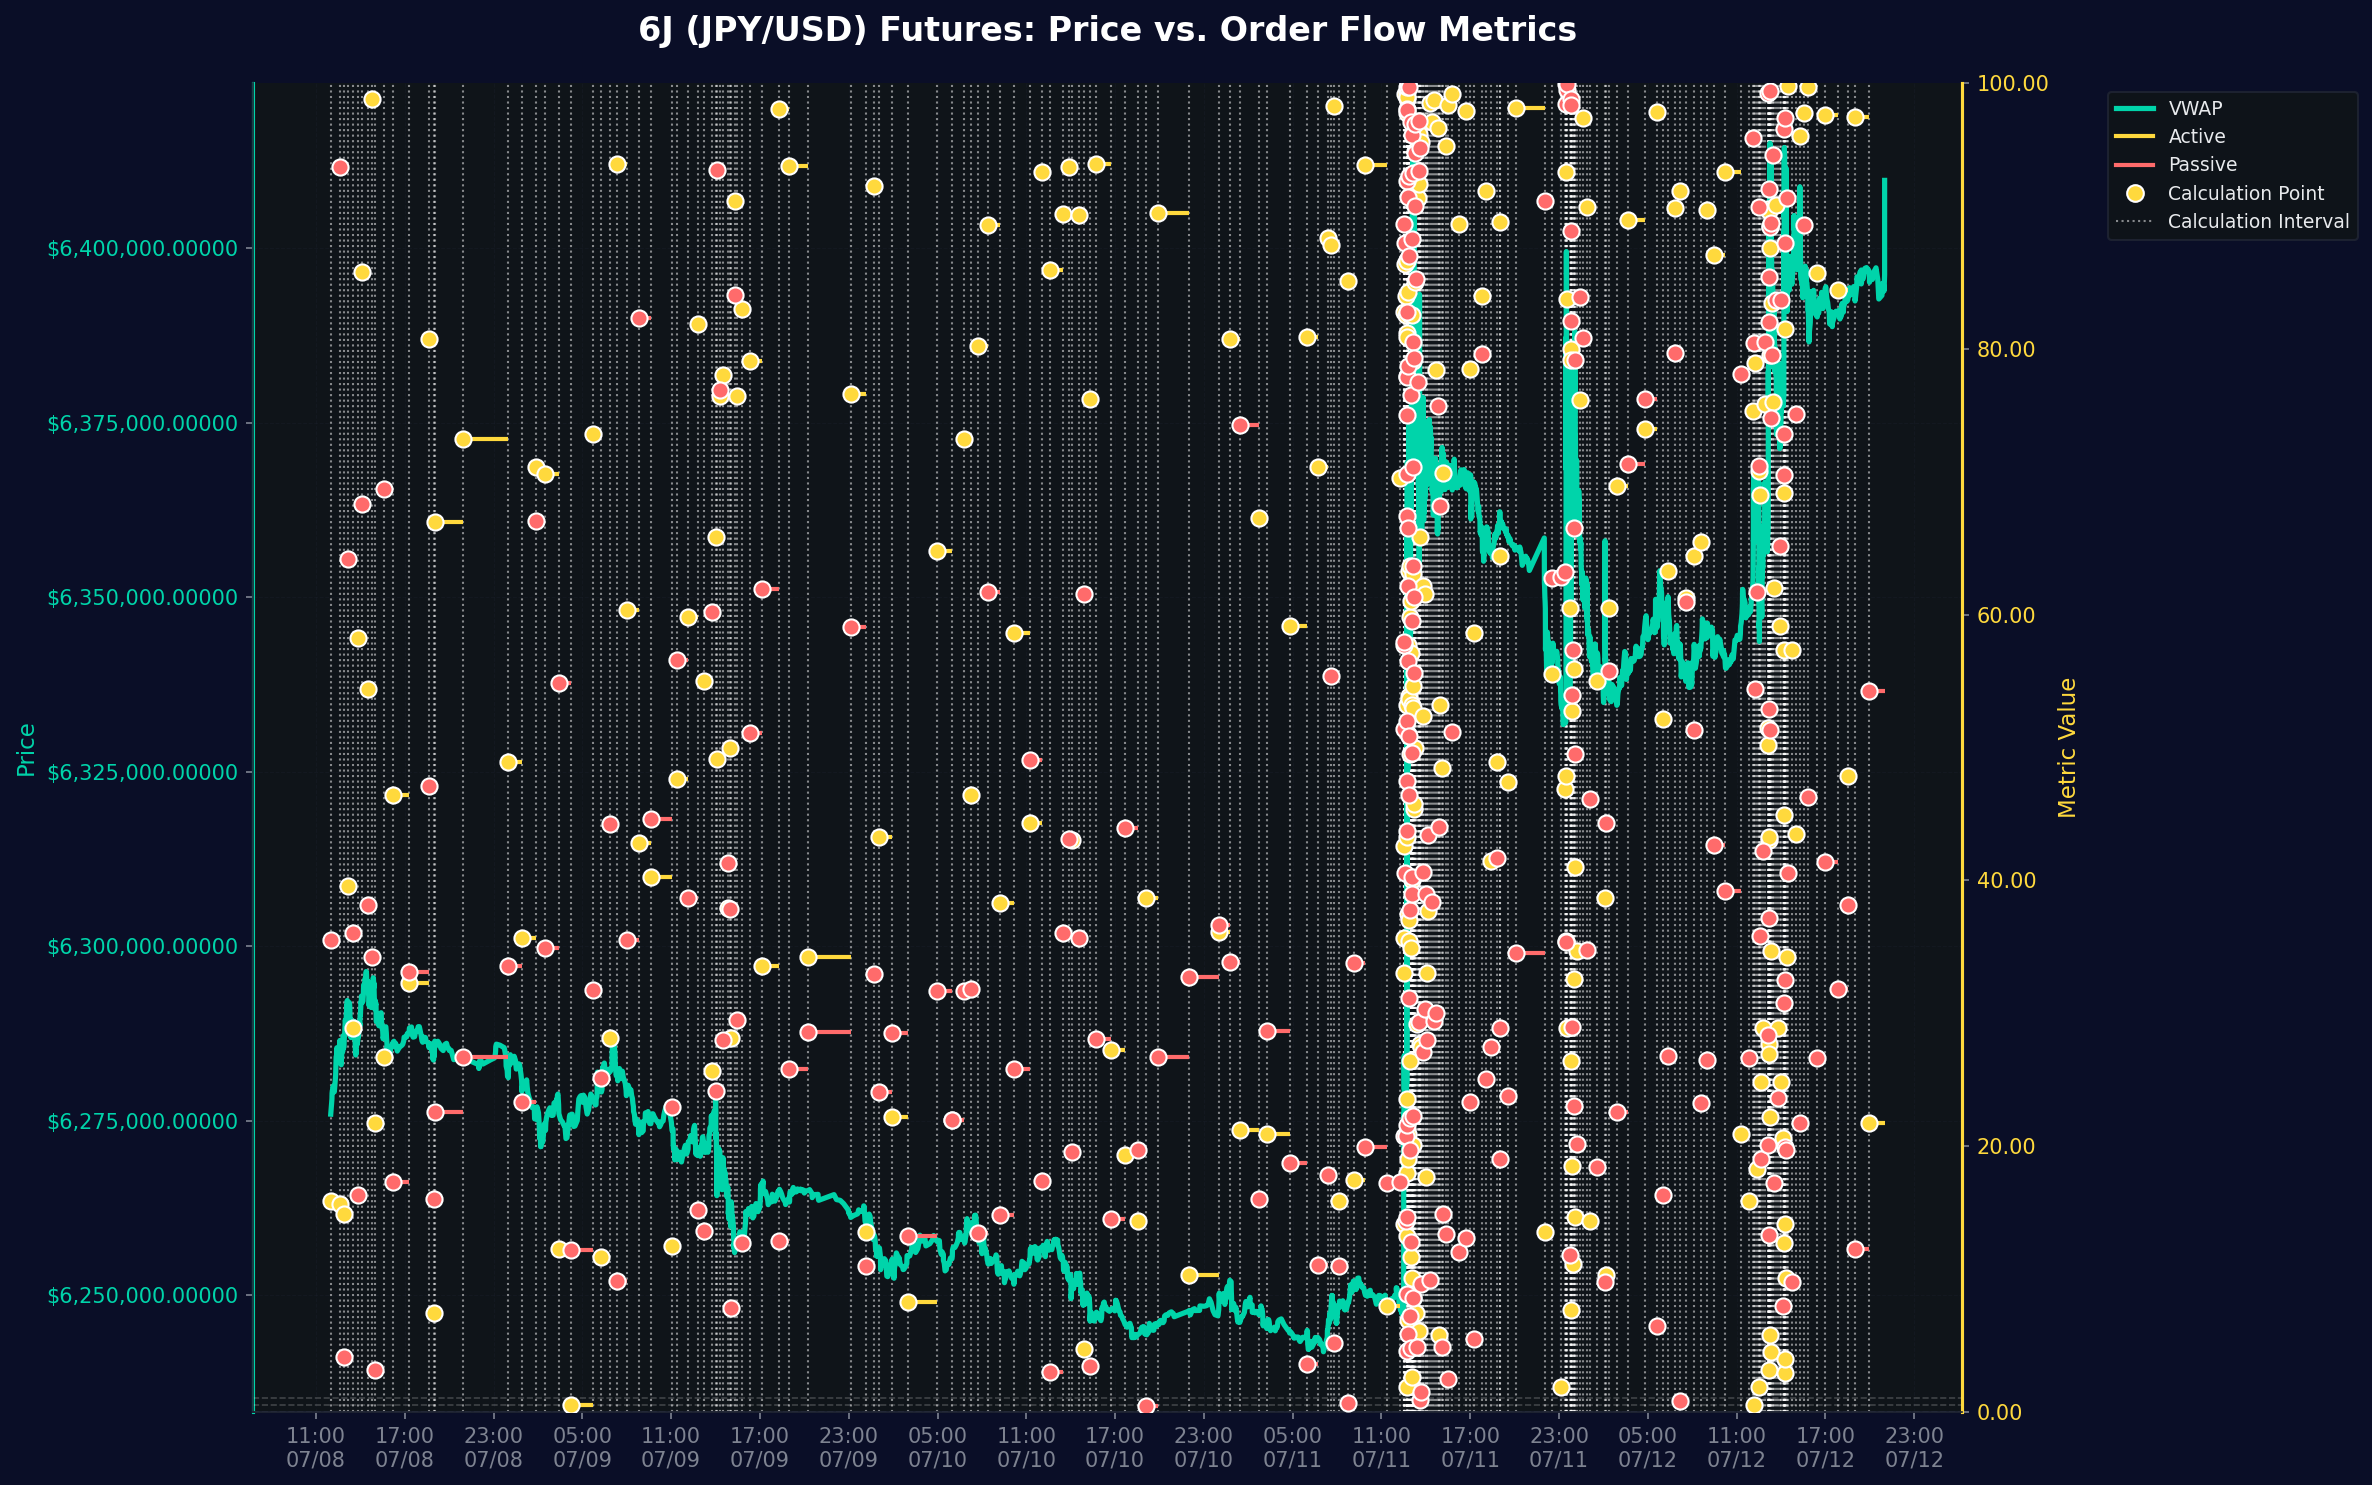

In [9]:
fig, (ax_price, ax_metrics) = plot_price_with_metrics(
    price_df=vb_lf,
    price_ts_col="end_ts_ns",
    price_col="passive_midprice",
    metrics_df=fb_lf,
    metrics_ts_col="end_ts_ns",
    metric_cols=["a", "b"],
    metric_labels=["Active", "Passive"], # not CDF values
    metric_range=(0, 100),
    title="6J (JPY/USD) Futures: Price vs. Order Flow Metrics",
    price_label="VWAP",
    show_calculation_guides=True,
)
plt.show()

In [10]:

"""

average container

"""

metrics_from_fb30 = (
    FB_DATA_GLOB
    .with_columns(
        metric=pl.int_range(pl.len()) // 5
    )
    .group_by("metric").agg([
        pl.col("id").first(),
        pl.col("start_ts_ns").first(),
        pl.col("end_ts_ns").last(),
        pl.col("time_elapsed_ns_total").sum().alias("time_elapsed_ns_total"),

        pl.col("active_imbalance_signed").sum().alias("total_active_imbalance_signed"),
        pl.col("passive_imbalance_signed").sum().alias("total_passive_imbalance_signed"),
    ])
    .sort("metric")
    .with_columns(
        pl.col("total_active_imbalance_signed").abs().alias("total_active_imbalance_abs"),
        pl.col("total_passive_imbalance_signed").abs().alias("total_passive_imbalance_abs"),
    )
    .with_columns([
        (pl.col("total_active_imbalance_signed").rank(method="average").truediv(pl.len()) * 100).alias("ecdf__total_active_imbalance_signed"),
        (pl.col("total_active_imbalance_abs").rank(method="average").truediv(pl.len()) * 100).alias("ecdf__total_active_imbalance_abs"),
        (pl.col("total_passive_imbalance_signed").rank(method="average").truediv(pl.len()) * 100).alias("ecdf__total_passive_imbalance_signed"),
        (pl.col("total_passive_imbalance_abs").rank(method="average").truediv(pl.len()) * 100).alias("ecdf__total_passive_imbalance_abs"),
    ])
    .drop("metric")
)


metrics_event = (
    metrics_from_fb30
    .filter(
        (pl.col("end_ts_ns").dt.epoch(time_unit="ns") >= START_DATE_NS) & 
        (pl.col("end_ts_ns").dt.epoch(time_unit="ns") <= END_DATE_NS)
    )
    .with_columns([
        pl.from_epoch(pl.col("end_ts_ns"), time_unit="ns").alias("end_ts_ns"),
        # (pl.col("time_elapsed_ns_mean") / 1e9).alias("time_elapsed_ns_mean"),
    ])
    # .select([
    #     "id",
    #     pl.col("start_ts_ns").dt.epoch(time_unit="ns").cast(pl.UInt64).alias("start_ts_ns"),
    #     pl.col("end_ts_ns").dt.epoch(time_unit="ns").cast(pl.UInt64).alias("end_ts_ns"),
    #     "time_elapsed_ns_total",
    # ])
).collect()

print(metrics_event)


shape: (61, 12)
┌───────┬────────────┬────────────┬────────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ id    ┆ start_ts_n ┆ end_ts_ns  ┆ time_elaps ┆ … ┆ ecdf__tot ┆ ecdf__tot ┆ ecdf__tot ┆ ecdf__tot │
│ ---   ┆ s          ┆ ---        ┆ ed_ns_tota ┆   ┆ al_active ┆ al_active ┆ al_passiv ┆ al_passiv │
│ u32   ┆ ---        ┆ datetime[n ┆ l          ┆   ┆ _imbalanc ┆ _imbalanc ┆ e_imbalan ┆ e_imbalan │
│       ┆ u64        ┆ s]         ┆ ---        ┆   ┆ e_s…      ┆ e_a…      ┆ ce_…      ┆ ce_…      │
│       ┆            ┆            ┆ u64        ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│       ┆            ┆            ┆            ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞═══════╪════════════╪════════════╪════════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 30255 ┆ 1720429103 ┆ 2024-07-08 ┆ 1412936824 ┆ … ┆ 85.088079 ┆ 67.260686 ┆ 88.706814 ┆ 75.747644 │
│       ┆ 939485942  ┆ 12:53:53.3 ┆ 8397       ┆   ┆           ┆           

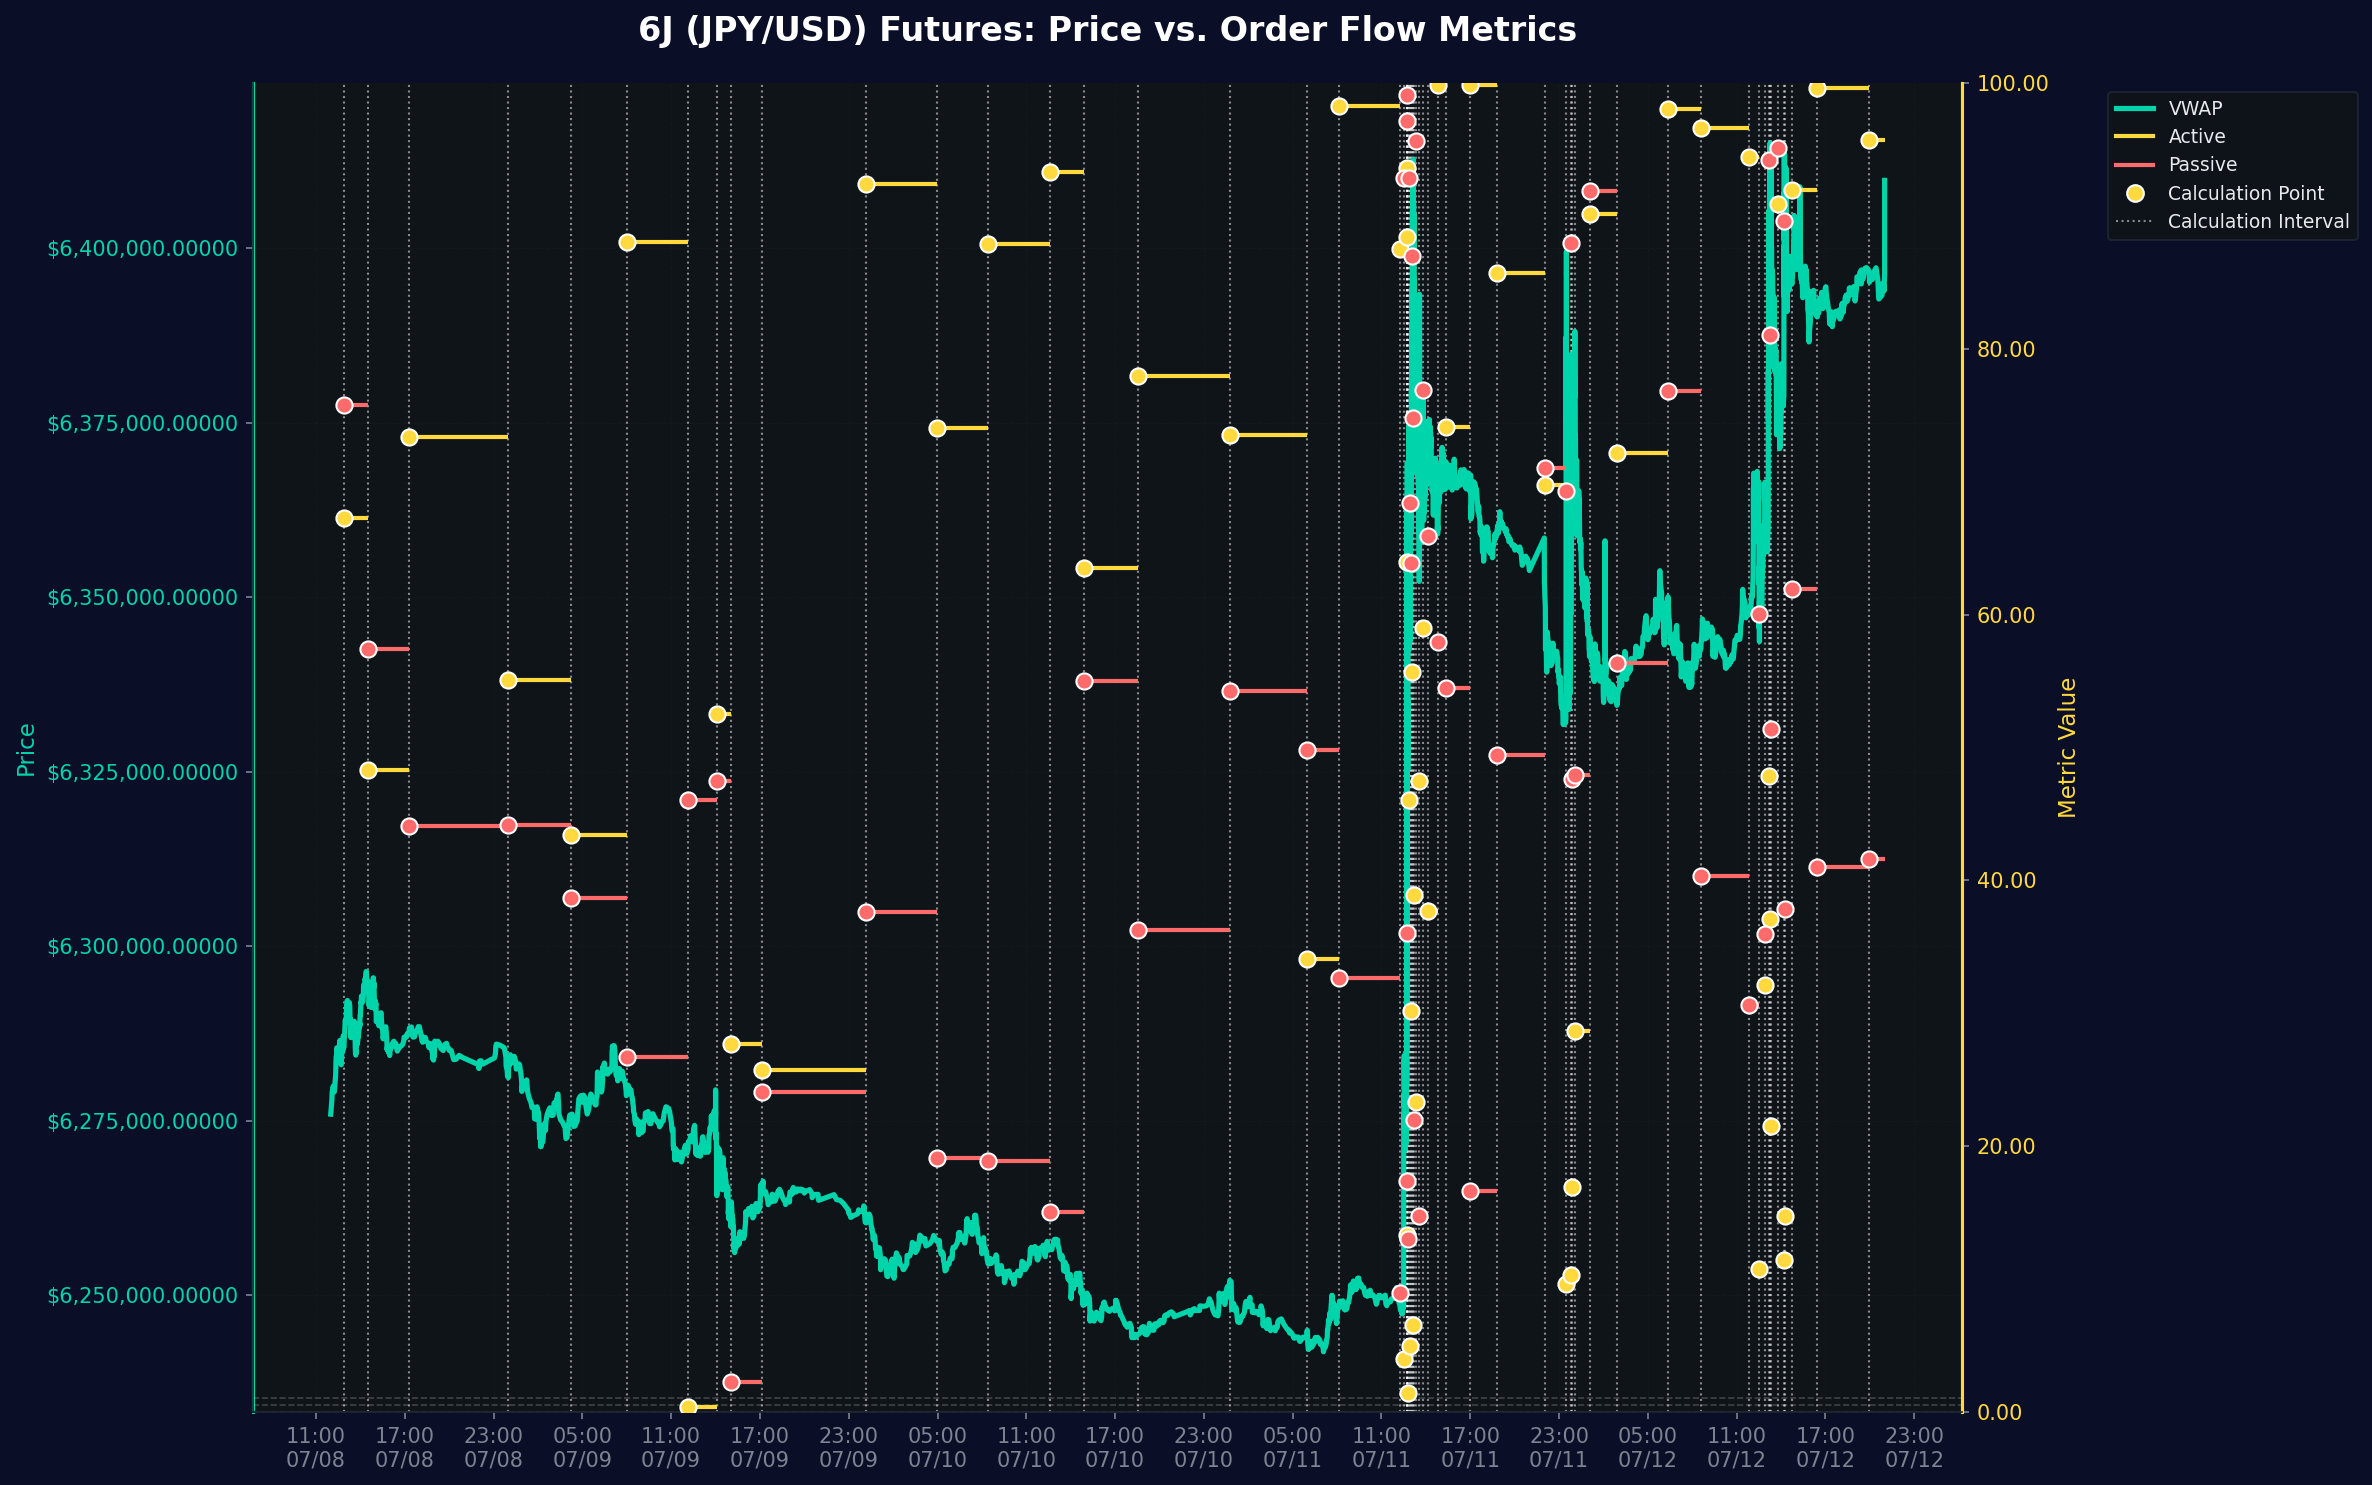

In [11]:
fig, (ax_price, ax_metrics) = plot_price_with_metrics(
    price_df=vb_lf,
    price_ts_col="end_ts_ns",
    price_col="passive_midprice",
    metrics_df=metrics_event,
    metrics_ts_col="end_ts_ns",
    metric_cols=["ecdf__total_active_imbalance_abs", "ecdf__total_passive_imbalance_abs"],
    metric_labels=["Active", "Passive"], # not CDF values
    metric_range=(0, 100),
    title="6J (JPY/USD) Futures: Price vs. Order Flow Metrics",
    price_label="VWAP",
    show_calculation_guides=True,
)
plt.show()

In [12]:

"""

average container

"""

r_window_size: int = 1

rolling_metrics_from_fb30 = (
    FB_DATA_GLOB
    .with_columns([
        pl.col("time_elapsed_ns_total").rolling_sum(window_size=r_window_size).alias("time_elapsed_ns_total_rolling"),
        pl.col("active_imbalance_signed").rolling_sum(window_size=r_window_size).alias("total_active_imbalance_signed"),
        pl.col("passive_imbalance_signed").rolling_sum(window_size=r_window_size).alias("total_passive_imbalance_signed"),
    ])
    # .drop_nulls()  # Remove first 4 rows that have incomplete windows
    .filter(
        pl.col("total_active_imbalance_signed").is_not_null()
    )
    .with_columns([
        pl.col("total_active_imbalance_signed").abs().alias("total_active_imbalance_abs"),
        pl.col("total_passive_imbalance_signed").abs().alias("total_passive_imbalance_abs"),
    ])
    .with_columns([
        (pl.col("total_active_imbalance_signed").rank(method="average").truediv(pl.len()) * 100).alias("ecdf__total_active_imbalance_signed"),
        (pl.col("total_active_imbalance_abs").rank(method="average").truediv(pl.len()) * 100).alias("ecdf__total_active_imbalance_abs"),
        (pl.col("total_passive_imbalance_signed").rank(method="average").truediv(pl.len()) * 100).alias("ecdf__total_passive_imbalance_signed"),
        (pl.col("total_passive_imbalance_abs").rank(method="average").truediv(pl.len()) * 100).alias("ecdf__total_passive_imbalance_abs"),
    ])
)


rolling_metrics_event = (
    rolling_metrics_from_fb30
    .filter(
        (pl.col("end_ts_ns").dt.epoch(time_unit="ns") >= START_DATE_NS) & 
        (pl.col("end_ts_ns").dt.epoch(time_unit="ns") <= END_DATE_NS)
    )
    .with_columns([
        pl.from_epoch(pl.col("end_ts_ns"), time_unit="ns").alias("end_ts_ns"),
        # (pl.col("time_elapsed_ns_mean") / 1e9).alias("time_elapsed_ns_mean"),
    ])
    # .select([
    #     "id",
    #     pl.col("start_ts_ns").dt.epoch(time_unit="ns").cast(pl.UInt64).alias("start_ts_ns"),
    #     pl.col("end_ts_ns").dt.epoch(time_unit="ns").cast(pl.UInt64).alias("end_ts_ns"),
    #     "time_elapsed_ns_total",
    # ])
).collect()

print(rolling_metrics_event)


shape: (303, 351)
┌───────┬────────────┬──────────┬────────────┬───┬────────────┬────────────┬───────────┬───────────┐
│ id    ┆ bucket_typ ┆ num_bars ┆ all_bars_c ┆ … ┆ ecdf__tota ┆ ecdf__tota ┆ ecdf__tot ┆ ecdf__tot │
│ ---   ┆ e          ┆ ---      ┆ omplete    ┆   ┆ l_active_i ┆ l_active_i ┆ al_passiv ┆ al_passiv │
│ u32   ┆ ---        ┆ u32      ┆ ---        ┆   ┆ mbalance_s ┆ mbalance_a ┆ e_imbalan ┆ e_imbalan │
│       ┆ str        ┆          ┆ bool       ┆   ┆ …          ┆ …          ┆ ce_…      ┆ ce_…      │
│       ┆            ┆          ┆            ┆   ┆ ---        ┆ ---        ┆ ---       ┆ ---       │
│       ┆            ┆          ┆            ┆   ┆ f64        ┆ f64        ┆ f64       ┆ f64       │
╞═══════╪════════════╪══════════╪════════════╪═══╪════════════╪════════════╪═══════════╪═══════════╡
│ 30257 ┆ fixed      ┆ 30       ┆ true       ┆ … ┆ 59.369879  ┆ 15.859554  ┆ 33.628319 ┆ 35.488364 │
│ 30258 ┆ fixed      ┆ 30       ┆ true       ┆ … ┆ 59.231946  ┆ 15.621927

In [13]:
fig, (ax_price, ax_metrics) = plot_price_with_metrics(
    price_df=rolling_metrics_event,#vb_lf
    price_ts_col="end_ts_ns",
    price_col="delta_passive_midprice_log",
    metrics_df=rolling_metrics_event,
    metrics_ts_col="end_ts_ns",
    metric_cols=["ecdf__total_active_imbalance_signed", "ecdf__total_passive_imbalance_signed"],
    metric_labels=["Active", "Passive"], # not CDF values
    metric_range=(0, 100),
    title="6J (JPY/USD) Futures: Price vs. Order Flow Metrics",
    price_label="VWAP",
    show_calculation_guides=True,
)
plt.show()

ColumnNotFoundError: unable to find column "delta_passive_midprice_log"; valid columns: ["id", "bucket_type", "num_bars", "all_bars_complete", "bar_volume_size", "contract_roll_any", "contract_roll_count", "latest_instrument_id", "start_ts_ns", "end_ts_ns", "time_elapsed_ns_total", "gap_return_any", "gap_return_count", "contains_oversized_order_any", "contains_oversized_order_count", "volume_total_sum", "volume_total_mean", "volume_total_std", "order_count_sum", "order_count_mean", "order_count_std", "order_splits_sum", "order_splits_mean", "delta_volume_total_log_mean", "delta_volume_total_log_std", "delta_volume_total_log_max", "delta_order_count_log_mean", "delta_order_count_log_std", "delta_order_count_log_max", "active_order_count_buy_sum", "active_order_count_buy_mean", "active_order_count_buy_std", "active_order_count_sell_sum", "active_order_count_sell_mean", "active_order_count_sell_std", "active_order_count_none_sum", "active_order_count_none_mean", "active_order_count_none_s

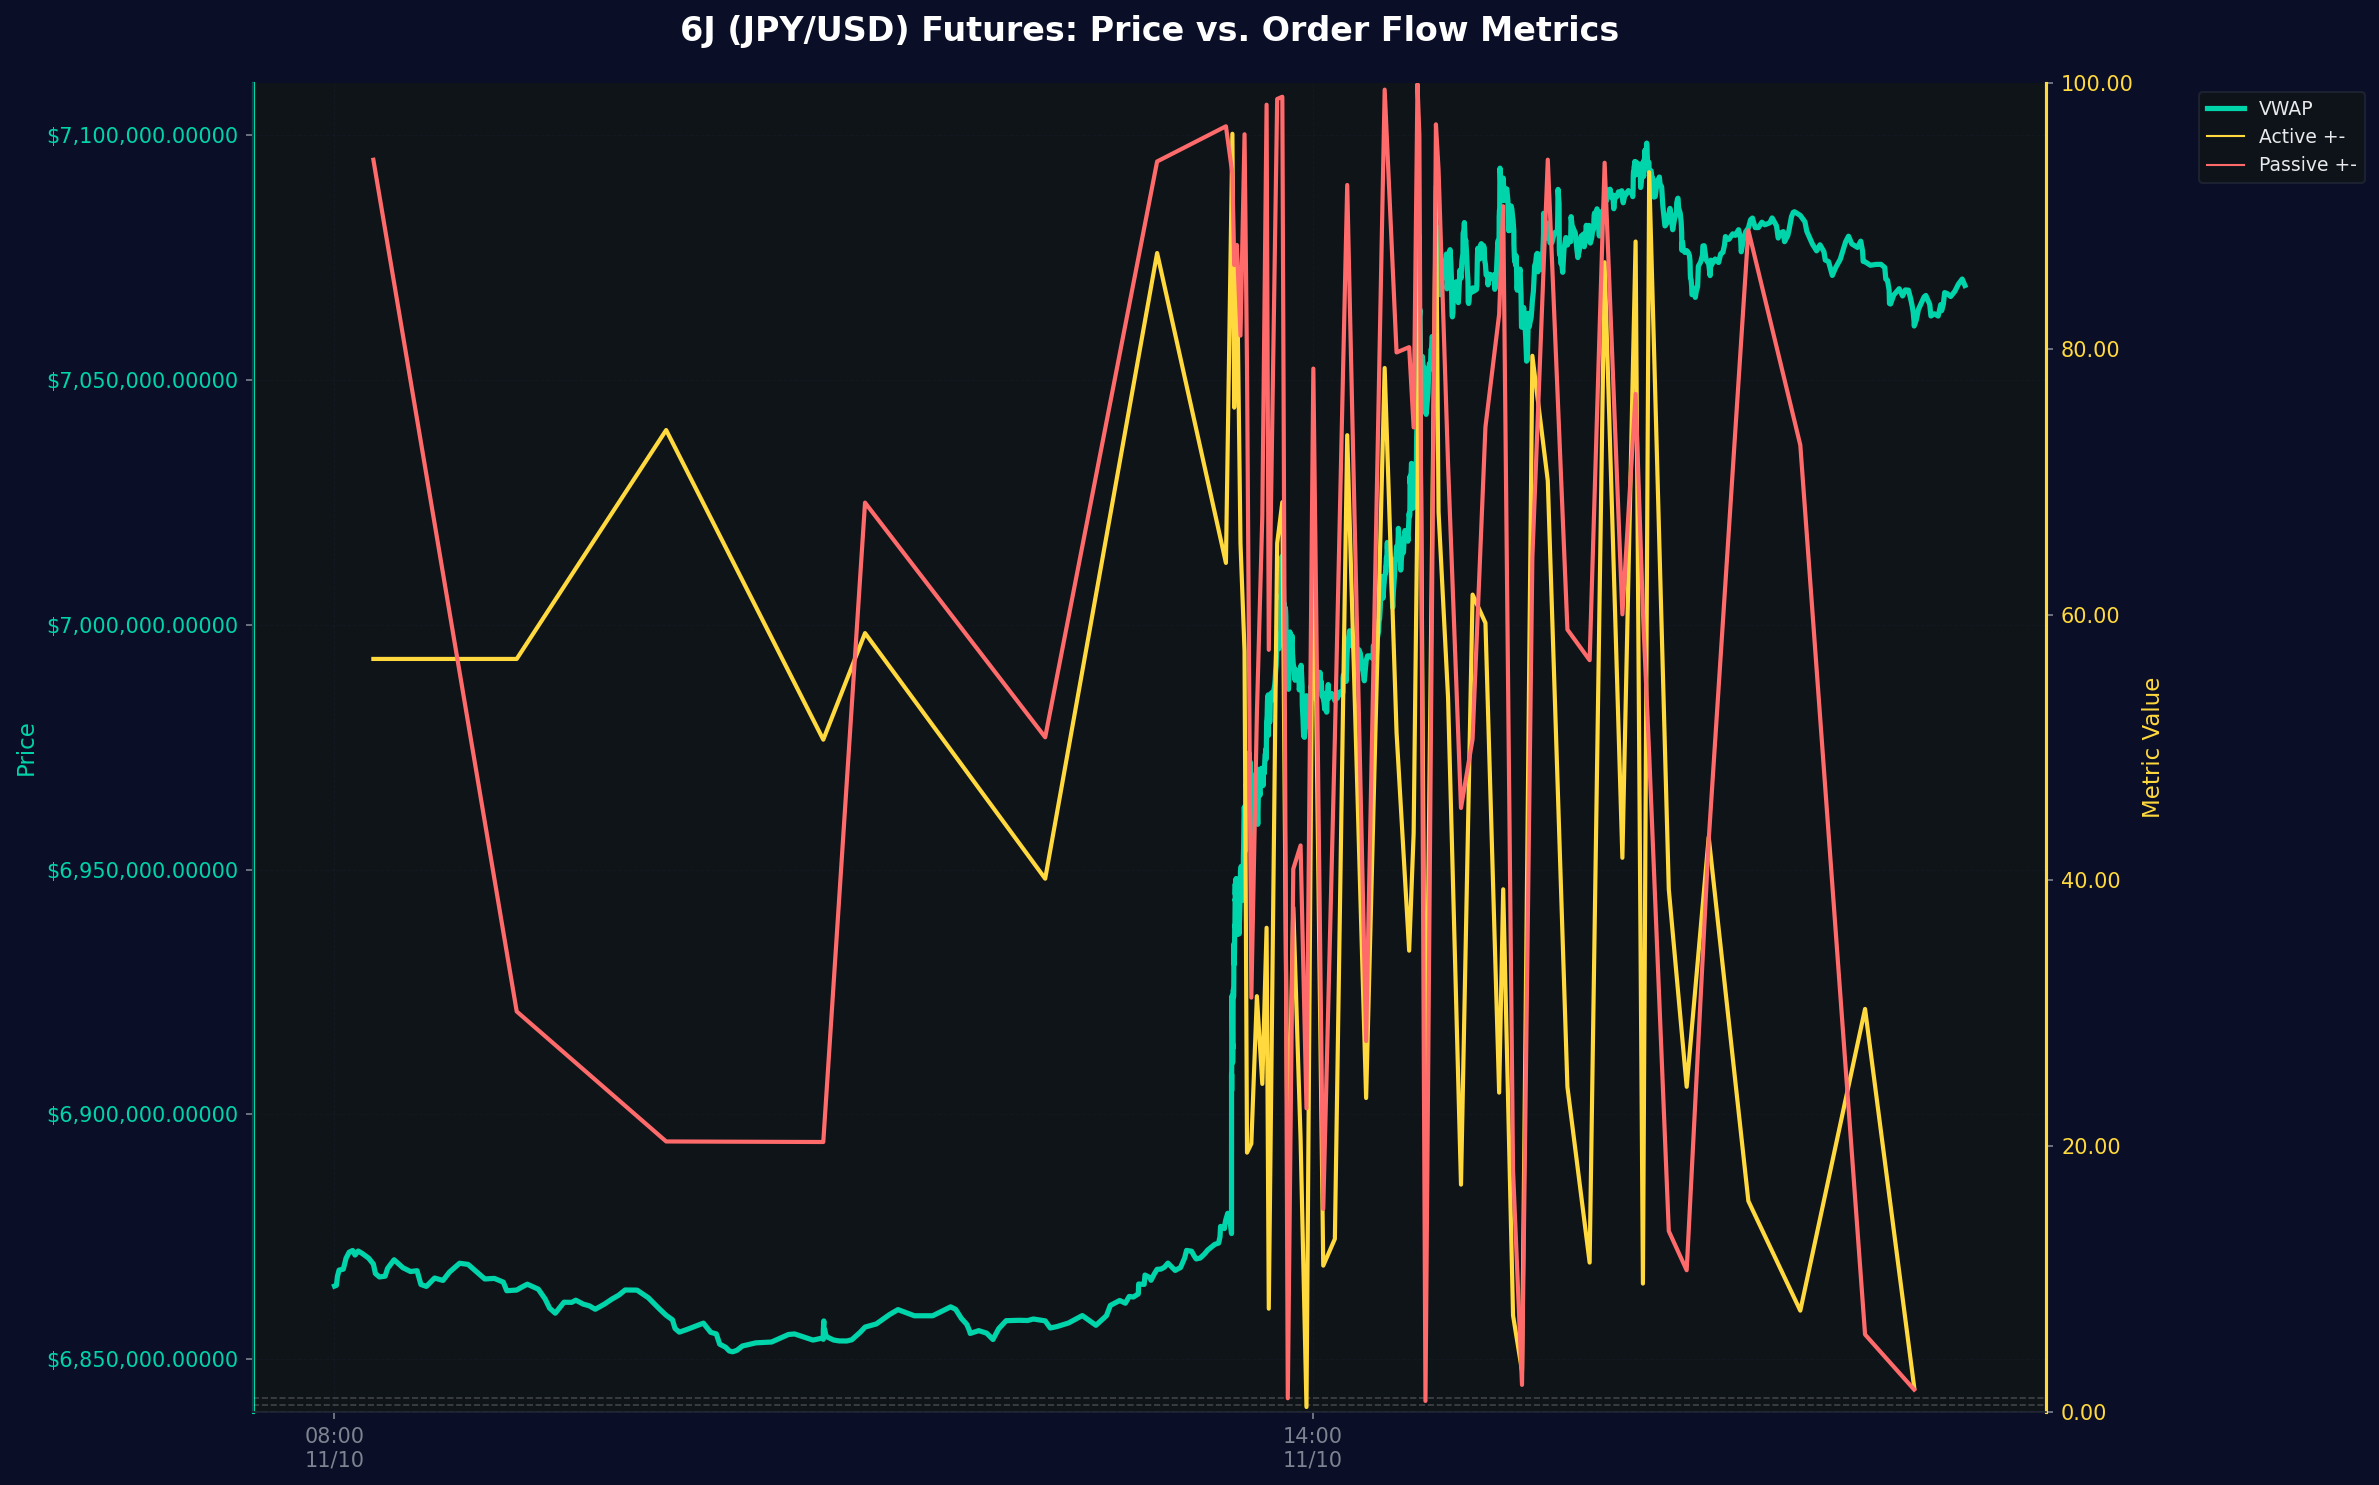

In [ ]:
fig, (ax_price, ax_metrics) = plot_price_with_metrics(
    price_df=vb_lf,
    price_ts_col="end_ts_ns",
    price_col="passive_midprice",
    metrics_df=rolling_metrics_event,
    metrics_ts_col="end_ts_ns",
    metric_cols=["ecdf__total_active_imbalance_signed", "ecdf__total_passive_imbalance_signed"], #, "ecdf__total_active_imbalance_abs", "ecdf__total_passive_imbalance_abs"],
    metric_labels=["Active +-", "Passive +-"], #, "Abs(Active)", "Abs(Passive)"], # not CDF values
    metric_range=(0, 100),
    title="6J (JPY/USD) Futures: Price vs. Order Flow Metrics",
    price_label="VWAP",
    show_calculation_guides=False,
    step_lines=False,
)
plt.show()

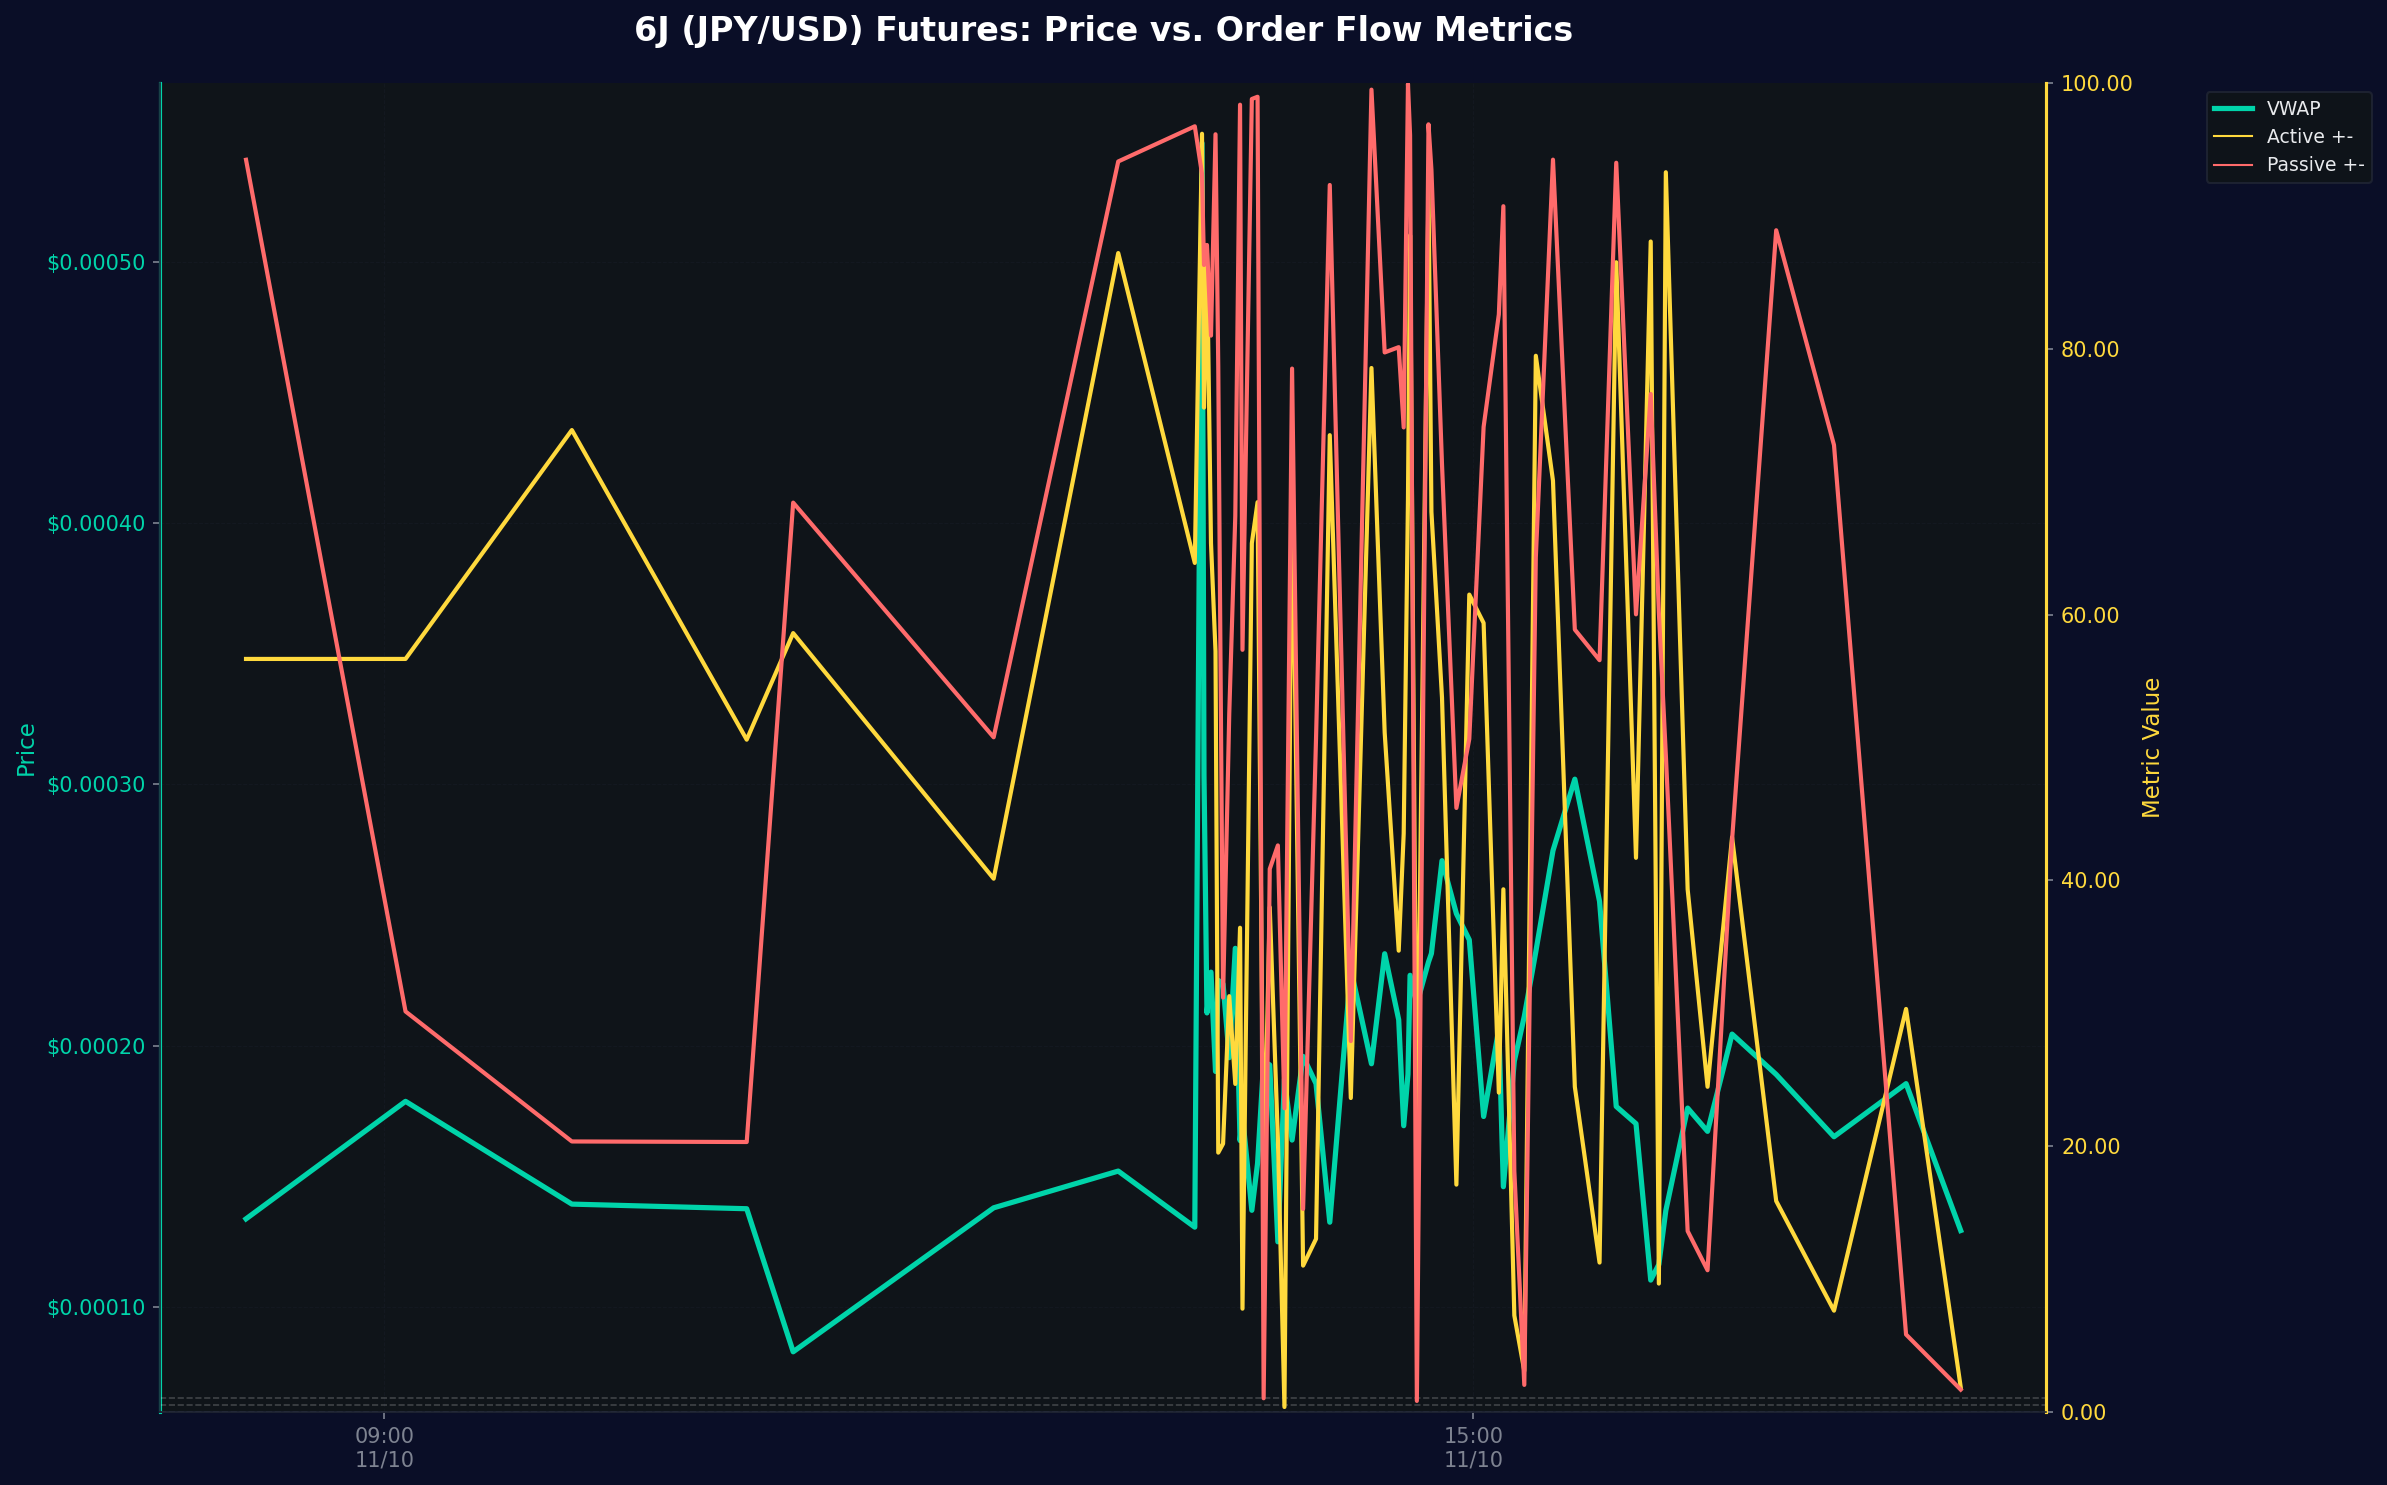

In [ ]:
fig, (ax_price, ax_metrics) = plot_price_with_metrics(
    price_df=rolling_metrics_event,
    price_ts_col="end_ts_ns",
    price_col="delta_passive_midprice_log_std",
    metrics_df=rolling_metrics_event,
    metrics_ts_col="end_ts_ns",
    metric_cols=["ecdf__total_active_imbalance_signed", "ecdf__total_passive_imbalance_signed"], #, "ecdf__total_active_imbalance_abs", "ecdf__total_passive_imbalance_abs"],
    metric_labels=["Active +-", "Passive +-"], #, "Abs(Active)", "Abs(Passive)"], # not CDF values
    metric_range=(0, 100),
    title="6J (JPY/USD) Futures: Price vs. Order Flow Metrics",
    price_label="VWAP",
    show_calculation_guides=False,
    step_lines=False,
)
plt.show()

In [ ]:

rolling_metrics_selecta = (
    rolling_metrics_from_fb30
    .select([
        "id",
        "ecdf__total_active_imbalance_signed",
        "ecdf__total_passive_imbalance_signed",
        "delta_passive_midprice_log_sum",
    ])
).collect()

# shift vpin up 1
# absolute value...

rolling_metrics_selecta

id,ecdf__total_active_imbalance_signed,ecdf__total_passive_imbalance_signed,delta_passive_midprice_log_sum
u32,f64,f64,f64
0,37.079373,2.542882,-0.001333
1,61.261335,49.830657,-0.000014
2,96.009505,39.271277,-0.000135
3,77.236971,30.328854,-0.000281
4,26.905113,39.790233,-0.000172
…,…,…,…
36607,50.439747,10.96635,-0.001088
36608,73.418551,4.848137,-0.001374
36609,98.210969,88.044903,0.000971


In [ ]:
comparison = "delta_passive_midprice_log_sum"
lookahead = 25

a_cols = [f"lead{i}_past_prediction__ecdf__total_active_imbalance_signed" for i in range(1, lookahead)]
b_cols = [f"lead{i}_past_prediction__ecdf__total_passive_imbalance_signed" for i in range(1, lookahead)]


rolling_metrics_selecta2 = (
    rolling_metrics_from_fb30
    .with_columns([
        # Generate Percent Return from Log Return
        (pl.col("delta_passive_midprice_log_sum").exp() - 1).abs().alias("delta_passive_midprice_pct_return"),

        *[pl.col("ecdf__total_active_imbalance_signed").log().shift(key).alias(col) for key, col in enumerate(a_cols)],
        *[pl.col("ecdf__total_passive_imbalance_signed").log().shift(key).alias(col) for key, col in enumerate(b_cols)],
    ])
    .select([
        "id",
        "delta_passive_midprice_pct_return",
        comparison,

        *a_cols,
        *b_cols,

    ])
).collect()

# shift vpin up 1
# absolute value...

# rolling_metrics_selecta2

correlations = pl.DataFrame({
    "PASSIVE_comparison": [f"returns_vs_last_vpin_{(key + 1)}" for key,col in enumerate(a_cols)],
    "PASSIVE_correlation": [rolling_metrics_selecta2.select(pl.corr(comparison, col)).item() for col in a_cols],
    "ACTIVE_comparison": [f"returns_vs_last_vpin_{(key + 1)}" for key,col in enumerate(b_cols)],
    "ACTIVE_correlation": [rolling_metrics_selecta2.select(pl.corr(comparison, col)).item() for col in b_cols],
})


print(correlations)

shape: (24, 4)
┌─────────────────────────┬─────────────────────┬─────────────────────────┬────────────────────┐
│ PASSIVE_comparison      ┆ PASSIVE_correlation ┆ ACTIVE_comparison       ┆ ACTIVE_correlation │
│ ---                     ┆ ---                 ┆ ---                     ┆ ---                │
│ str                     ┆ f64                 ┆ str                     ┆ f64                │
╞═════════════════════════╪═════════════════════╪═════════════════════════╪════════════════════╡
│ returns_vs_last_vpin_1  ┆ 0.076143            ┆ returns_vs_last_vpin_1  ┆ 0.259774           │
│ returns_vs_last_vpin_2  ┆ -0.010564           ┆ returns_vs_last_vpin_2  ┆ 0.003644           │
│ returns_vs_last_vpin_3  ┆ -0.011195           ┆ returns_vs_last_vpin_3  ┆ 0.002853           │
│ returns_vs_last_vpin_4  ┆ -0.012666           ┆ returns_vs_last_vpin_4  ┆ 0.002651           │
│ returns_vs_last_vpin_5  ┆ -0.012742           ┆ returns_vs_last_vpin_5  ┆ 0.000272           │
│ …            

In [ ]:
300**3

27000000